# BVP → HR / HRV 변환 데모 (WESAD S10)

WESAD 데이터셋의 E4 손목 센서 BVP(Blood Volume Pulse) 신호를 이용해  
**HR(Heart Rate, 심박수)** 와 **HRV(Heart Rate Variability, 심박변이도)** 를 계산하는 과정을 단계별로 시각화합니다.

| 항목 | 내용 |
|------|------|
| 센서 | E4 Wristband – BVP |
| 샘플링 레이트 | **64 Hz** |
| 방법 | Peak Detection → RR Interval → HR / RMSSD |

In [4]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.signal import find_peaks, butter, filtfilt

DATASET_PATH = "/home/binghin2/Myproject/Dataset/WESAD"
SUBJECT      = "S10"
BVP_FS       = 64      # E4 BVP sampling rate (Hz)
LABEL_FS     = 700     # WESAD label sampling rate (Hz)

# 라벨 색상 (0=Baseline, 1=Stress, 2=Amusement)
LABEL_COLORS = {0: '#90CAF9', 1: '#EF9A9A', 2: '#A5D6A7'}
LABEL_NAMES  = {0: 'Baseline', 1: 'Stress', 2: 'Amusement'}

print("Libraries loaded.")

Libraries loaded.


In [5]:
## ── 1. 데이터 로드 ──────────────────────────────────────────────
pkl_path = f"{DATASET_PATH}/{SUBJECT}/{SUBJECT}.pkl"
with open(pkl_path, 'rb') as f:
    data = pickle.load(f, encoding='latin1')

# BVP: wrist E4 센서, shape = (N,)
bvp_raw = data['signal']['wrist']['BVP'].flatten()

# 라벨 (700 Hz), 관심 라벨: 1=Baseline, 2=Stress, 3=Amusement
labels_raw = data['label'].flatten()

# 라벨 리맵핑: 1→0, 2→1, 3→2 (0=baseline, 4=meditation 제외)
label_map = {1: 0, 2: 1, 3: 2}

# BVP 시간축 (초)
t_bvp = np.arange(len(bvp_raw)) / BVP_FS
# 라벨 시간축 (초)
t_label = np.arange(len(labels_raw)) / LABEL_FS

print(f"Subject     : {SUBJECT}")
print(f"BVP samples : {len(bvp_raw):,}  ({len(bvp_raw)/BVP_FS:.1f} sec)")
print(f"Label samples: {len(labels_raw):,}")
print(f"Label unique : {np.unique(labels_raw)}")

Subject     : S10
BVP samples : 351,744  (5496.0 sec)
Label samples: 3,847,200
Label unique : [0 1 2 3 4 5 6 7]


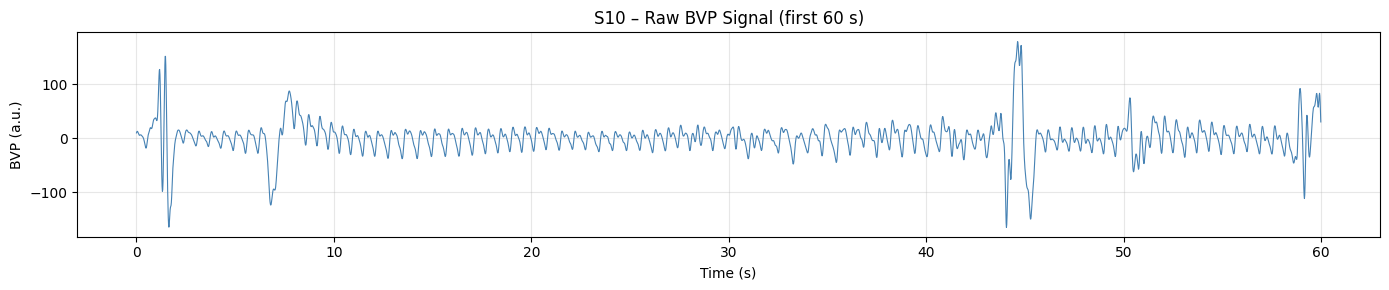

In [6]:
## ── 2. 원시 BVP 신호 시각화 (처음 60초) ──────────────────────────
seg_sec  = 60
seg_samp = seg_sec * BVP_FS

fig, ax = plt.subplots(figsize=(14, 3))
ax.plot(t_bvp[:seg_samp], bvp_raw[:seg_samp], color='steelblue', lw=0.8)
ax.set_xlabel("Time (s)")
ax.set_ylabel("BVP (a.u.)")
ax.set_title(f"{SUBJECT} – Raw BVP Signal (first {seg_sec} s)")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

검출된 Peak 수: 7846
평균 Peak 간격: 700.3 ms


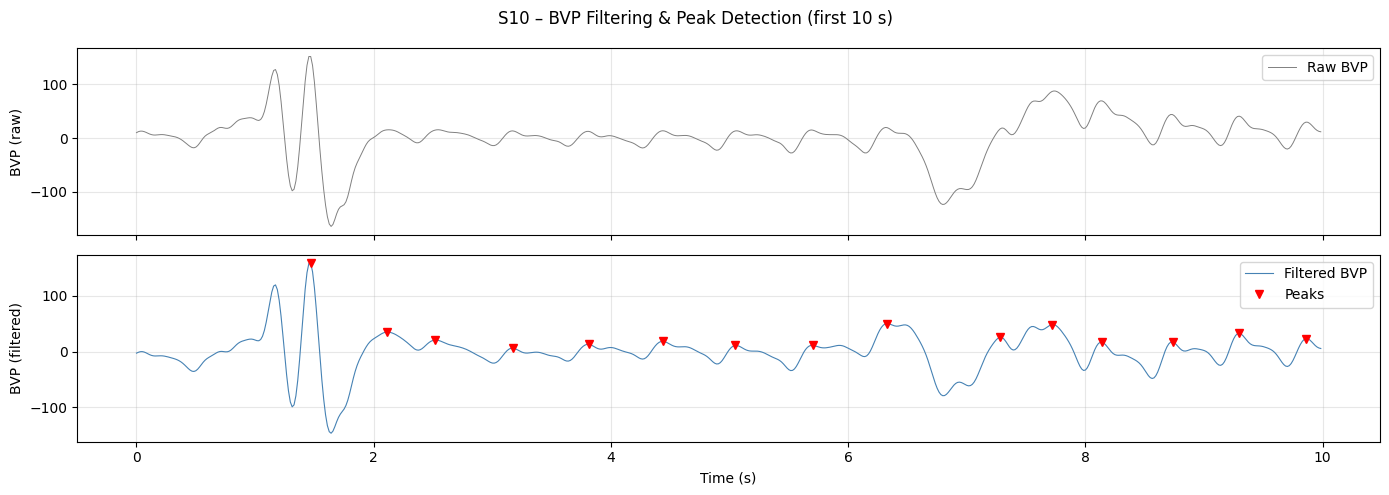

In [7]:
## ── 3. BVP 전처리 + Peak (맥박) 검출 ────────────────────────────
def bandpass_filter(signal, fs, lowcut=0.5, highcut=8.0, order=4):
    """BVP용 대역통과 필터 (0.5~8 Hz)"""
    nyq = fs / 2.0
    b, a = butter(order, [lowcut / nyq, highcut / nyq], btype='band')
    return filtfilt(b, a, signal)

# 필터링
bvp_filt = bandpass_filter(bvp_raw, BVP_FS)

# Peak 검출: BVP는 맥박마다 양의 피크 발생
#  - distance: 최소 0.4초 간격 (최대 ~150 bpm)
#  - prominence: 노이즈 피크 억제
peaks, props = find_peaks(bvp_filt,
                          distance=int(0.4 * BVP_FS),
                          prominence=0.3 * np.std(bvp_filt))

print(f"검출된 Peak 수: {len(peaks)}")
print(f"평균 Peak 간격: {np.mean(np.diff(peaks)) / BVP_FS * 1000:.1f} ms")

# 시각화 (처음 10초)
seg10 = 10 * BVP_FS
mask = peaks < seg10

fig, axes = plt.subplots(2, 1, figsize=(14, 5), sharex=True)

axes[0].plot(t_bvp[:seg10], bvp_raw[:seg10], color='gray', lw=0.7, label='Raw BVP')
axes[0].set_ylabel("BVP (raw)"); axes[0].legend(loc='upper right'); axes[0].grid(alpha=0.3)

axes[1].plot(t_bvp[:seg10], bvp_filt[:seg10], color='steelblue', lw=0.8, label='Filtered BVP')
axes[1].plot(t_bvp[peaks[mask]], bvp_filt[peaks[mask]], 'rv', ms=6, label='Peaks')
axes[1].set_xlabel("Time (s)"); axes[1].set_ylabel("BVP (filtered)")
axes[1].legend(loc='upper right'); axes[1].grid(alpha=0.3)

plt.suptitle(f"{SUBJECT} – BVP Filtering & Peak Detection (first 10 s)")
plt.tight_layout()
plt.show()

In [11]:
## ── 4. RR Interval → HR 계산 ─────────────────────────────────────
# Peak 위치(샘플) → 시간(초)
peak_times = peaks / BVP_FS          # 단위: 초

# RR 간격 (연속 Peak 사이의 시간 차이, 단위: 초)
rr_intervals = np.diff(peak_times)   # shape: (N_peaks - 1,)

# RR 간격의 시간축: 두 Peak의 중간 시각
rr_times = (peak_times[:-1] + peak_times[1:]) / 2.0

# HR = 60 / RR (bpm)
hr = 60.0 / rr_intervals

# 이상치 제거 (30~200 bpm 범위 밖 제거)
valid = (hr >= 30) & (hr <= 200)
rr_times_v = rr_times[valid]
rr_v        = rr_intervals[valid]
hr_v        = hr[valid]

print(f"유효 RR 수  : {valid.sum()} / {len(rr_intervals)}")
print(f"평균 HR    : {hr_v.mean():.1f} bpm")
print(f"HR 범위    : {hr_v.min():.1f} ~ {hr_v.max():.1f} bpm")

유효 RR 수  : 7838 / 7845
평균 HR    : 91.2 bpm
HR 범위    : 30.0 ~ 153.6 bpm


In [12]:
## ── 5. 슬라이딩 윈도우 HRV 계산 (RMSSD, SDNN) ──────────────────
# 30초 윈도우, 1초 스텝으로 HRV 지표 계산
WIN_SEC  = 30
STEP_SEC = 1

hrv_times  = []
hrv_rmssd  = []   # RMSSD: Root Mean Square of Successive Differences
hrv_sdnn   = []   # SDNN : Std of NN intervals

t_end = rr_times_v[-1]
t_start = rr_times_v[0] + WIN_SEC

t_cur = t_start
while t_cur <= t_end:
    mask_win = (rr_times_v >= t_cur - WIN_SEC) & (rr_times_v < t_cur)
    rr_win = rr_v[mask_win]
    if len(rr_win) >= 5:
        succ_diff = np.diff(rr_win)
        rmssd = np.sqrt(np.mean(succ_diff ** 2)) * 1000   # ms
        sdnn  = np.std(rr_win) * 1000                     # ms
        hrv_times.append(t_cur)
        hrv_rmssd.append(rmssd)
        hrv_sdnn.append(sdnn)
    t_cur += STEP_SEC

hrv_times  = np.array(hrv_times)
hrv_rmssd  = np.array(hrv_rmssd)
hrv_sdnn   = np.array(hrv_sdnn)

print(f"HRV 포인트 수 : {len(hrv_times)}")
print(f"평균 RMSSD   : {hrv_rmssd.mean():.1f} ms")
print(f"평균 SDNN    : {hrv_sdnn.mean():.1f} ms")

HRV 포인트 수 : 5464
평균 RMSSD   : 215.5 ms
평균 SDNN    : 157.6 ms


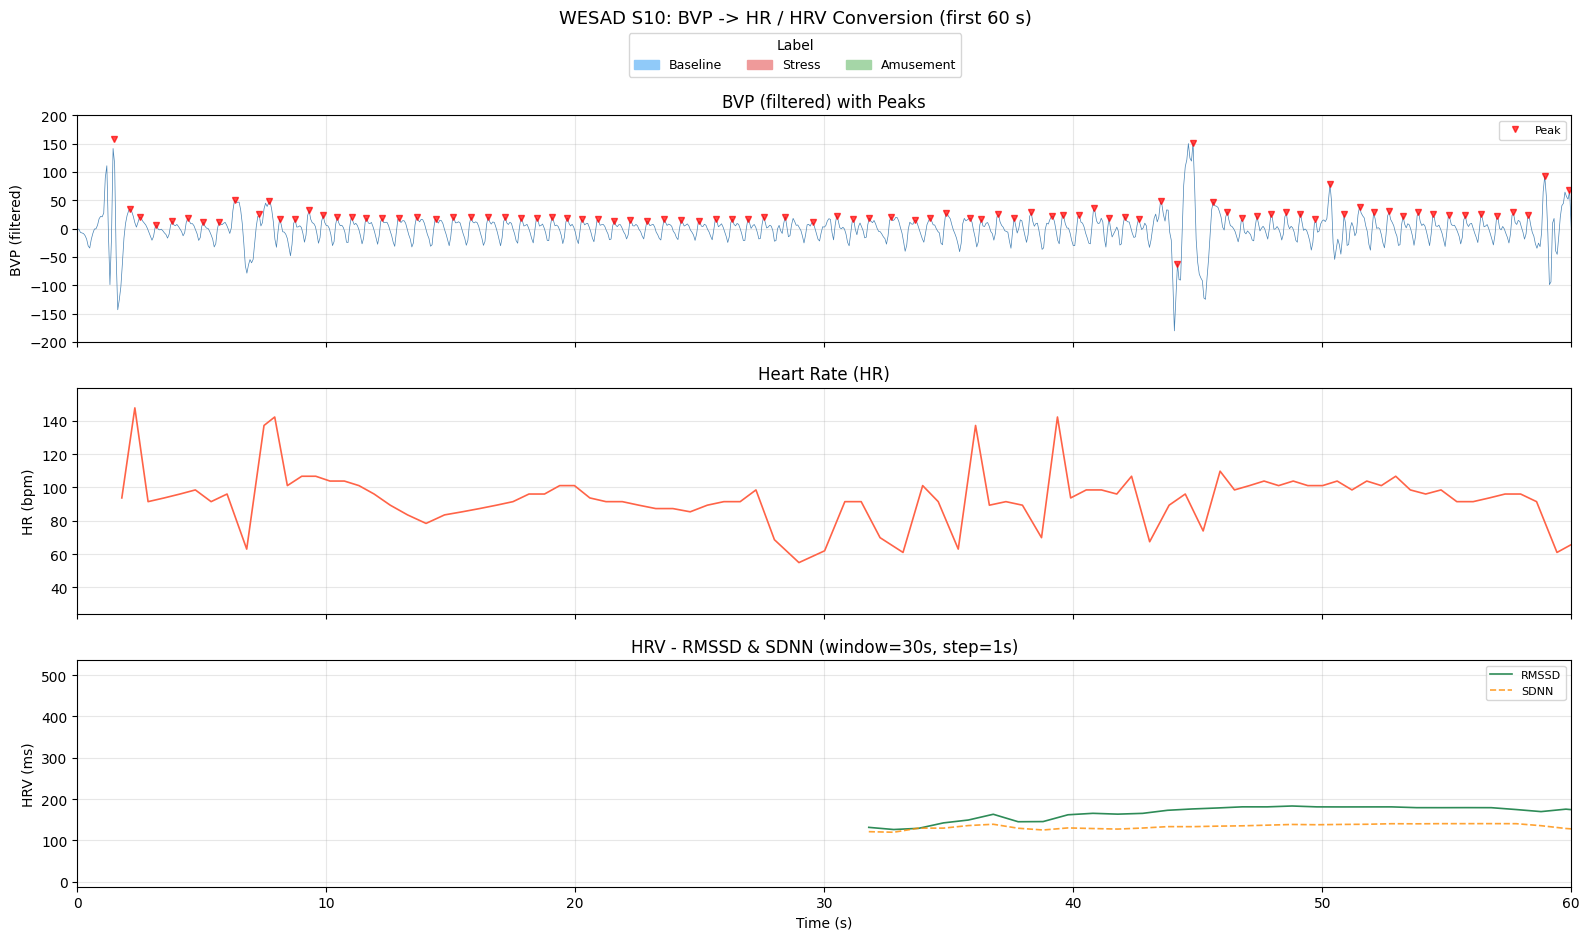

In [17]:
## ── 6. 라벨별 배경색 헬퍼 ────────────────────────────────────────
def add_label_background(ax, t_label, labels_raw, label_map, alpha=0.25):
    t_ref  = np.arange(len(bvp_raw)) / BVP_FS
    lbl_at_bvp = np.interp(t_ref, t_label, labels_raw.astype(float)).astype(int)

    prev_lbl = -1
    seg_start = 0
    for i, lbl in enumerate(lbl_at_bvp):
        if lbl != prev_lbl:
            if prev_lbl in label_map:
                ax.axvspan(t_ref[seg_start], t_ref[i],
                           color=LABEL_COLORS[label_map[prev_lbl]], alpha=alpha)
            seg_start = i
            prev_lbl = lbl
    if prev_lbl in label_map:
        ax.axvspan(t_ref[seg_start], t_ref[-1],
                   color=LABEL_COLORS[label_map[prev_lbl]], alpha=alpha)


## ── 7. HR + HRV 종합 시각화 (처음 60초) ─────────────────────────
VIEW_SEC = 60   # 표시할 구간 (초)

fig, axes = plt.subplots(3, 1, figsize=(16, 9), sharex=True)

# ── (a) 필터된 BVP ──
step = 4
axes[0].plot(t_bvp[::step], bvp_filt[::step], color='steelblue', lw=0.5)
axes[0].plot(t_bvp[peaks], bvp_filt[peaks], 'rv', ms=4, alpha=0.7, label='Peak')
add_label_background(axes[0], t_label, labels_raw, label_map)
axes[0].set_xlim(0, VIEW_SEC)
axes[0].set_ylim(-200, 200)
axes[0].set_ylabel("BVP (filtered)")
axes[0].legend(loc='upper right', fontsize=8)
axes[0].grid(alpha=0.3)
axes[0].set_title("BVP (filtered) with Peaks")

# ── (b) HR ──
axes[1].plot(rr_times_v, hr_v, color='tomato', lw=1.2)
add_label_background(axes[1], t_label, labels_raw, label_map)
axes[1].set_xlim(0, VIEW_SEC)
axes[1].set_ylabel("HR (bpm)")
axes[1].grid(alpha=0.3)
axes[1].set_title("Heart Rate (HR)")

# ── (c) HRV (RMSSD, SDNN) ──
axes[2].plot(hrv_times, hrv_rmssd, color='seagreen', lw=1.2, label='RMSSD')
axes[2].plot(hrv_times, hrv_sdnn,  color='darkorange', lw=1.2, ls='--', label='SDNN', alpha=0.8)
add_label_background(axes[2], t_label, labels_raw, label_map)
axes[2].set_xlim(0, VIEW_SEC)
axes[2].set_xlabel("Time (s)")
axes[2].set_ylabel("HRV (ms)")
axes[2].legend(loc='upper right', fontsize=8)
axes[2].grid(alpha=0.3)
axes[2].set_title(f"HRV - RMSSD & SDNN (window={WIN_SEC}s, step={STEP_SEC}s)")

# 범례 패치
patches = [mpatches.Patch(color=LABEL_COLORS[v], label=LABEL_NAMES[v])
           for v in LABEL_NAMES]
fig.legend(handles=patches, loc='upper center', ncol=3, fontsize=9,
           title="Label", bbox_to_anchor=(0.5, 1.02))

plt.suptitle(f"WESAD {SUBJECT}: BVP -> HR / HRV Conversion (first {VIEW_SEC} s)", y=1.04, fontsize=13)
plt.tight_layout()
plt.show()
